<a href="https://colab.research.google.com/github/Gargee2502/WSN-DS-Intrusion-Detection/blob/main/WSN_Reasearch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving WSN-DS.csv to WSN-DS.csv


In [ ]:
!pip install optuna imbalanced-learn xgboost seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 8.3 MB/s eta 0:00:00


In [ ]:
# Section 1: imports & settings
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, accuracy_score,
                             f1_score, recall_score, precision_score)

from imblearn.over_sampling import SMOTE

# Optuna + XGBoost for optimization-based model
import optuna
import xgboost as xgb

# For multi-class ROC (one-vs-rest)
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

# reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# file paths
DATA_PATH = "WSN-DS.csv"   # change if needed
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [ ]:
# Section 2: load dataset
df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
display(df.head())

# Missing values analysis
missing_counts = df.isna().sum()
missing_percent = (missing_counts / len(df) * 100).round(4)
missing_df = pd.DataFrame({'missing_count': missing_counts, 'missing_pct': missing_percent})
print("Missing values per column:")
display(missing_df.sort_values('missing_count', ascending=False))

Dataset shape: (374661, 19)


,id,Time,Is_CH,who CH,Dist_To_CH,ADV_S,ADV_R,JOIN_S,JOIN_R,SCH_S,SCH_R,Rank,DATA_S,DATA_R,Data_Sent_To_BS,dist_CH_To_BS,send_code,Expaned Energy,Attack type
0,101000,50,1,101000,0.00000,1,0,0,25,1,0,0,0,1200,48,130.08535,0,2.46940,Normal
1,101001,50,0,101044,75.32345,0,4,1,0,0,1,2,38,0,0,0.00000,4,0.06957,Normal
2,101002,50,0,101010,46.95453,0,4,1,0,0,1,19,41,0,0,0.00000,3,0.06898,Normal
3,101003,50,0,101044,64.85231,0,4,1,0,0,1,16,38,0,0,0.00000,4,0.06673,Normal
4,101004,50,0,101010,4.83341,0,4,1,0,0,1,25,41,0,0,0.00000,3,0.06534,Normal


Missing values per column:


,missing_count,missing_pct
id,0,0.0
Time,0,0.0
Is_CH,0,0.0
who CH,0,0.0
Dist_To_CH,0,0.0
ADV_S,0,0.0
ADV_R,0,0.0
JOIN_S,0,0.0
JOIN_R,0,0.0
SCH_S,0,0.0


In [ ]:
# Example simple imputation (only run if you have missing values)
from sklearn.impute import SimpleImputer

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])


In [ ]:
# Section 3: features & target
TARGET_COL = 'Attack type'  # adjust if column name differs: check df.columns
if TARGET_COL not in df.columns:
    # try common alternatives
    for c in df.columns:
        if 'attack' in c.lower():
            TARGET_COL = c
            break
print("Using target column:", TARGET_COL)

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL].astype(str)

# Label encode target for classifiers
le = LabelEncoder()
y_enc = le.fit_transform(y)
classes = le.classes_
print("Classes:", classes)

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.20, random_state=RANDOM_STATE, stratify=y_enc)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Using target column: Attack type
Classes: ['Blackhole' 'Flooding' 'Grayhole' 'Normal' 'TDMA']
Train shape: (299728, 18) Test shape: (74933, 18)


In [ ]:
# Section 4: count distribution before SMOTE
from collections import Counter
print("Train distribution before SMOTE:", Counter(y_train))

# Choose numeric columns for SMOTE; if there are categorical features,
# encode/one-hot them before SMOTE (SMOTE expects numeric vectors).
# We'll assume dataset features are numeric (typical for WSN-DS).
sm = SMOTE(random_state=RANDOM_STATE)

X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("After SMOTE distribution:", Counter(y_train_res))
print("Shapes before SMOTE:", X_train.shape, y_train.shape)
print("Shapes after SMOTE:", X_train_res.shape, y_train_res.shape)

# Optional: show counts per class before/after in a DataFrame
before = pd.Series(y_train).value_counts().sort_index()
after = pd.Series(y_train_res).value_counts().sort_index()
res_counts = pd.DataFrame({'before': before, 'after': after})
res_counts.index = le.inverse_transform(res_counts.index)
display(res_counts)


Train distribution before SMOTE: Counter({np.int64(3): 272052, np.int64(2): 11677, np.int64(0): 8039, np.int64(4): 5310, np.int64(1): 2650})
After SMOTE distribution: Counter({np.int64(3): 272052, np.int64(2): 272052, np.int64(4): 272052, np.int64(1): 272052, np.int64(0): 272052})
Shapes before SMOTE: (299728, 18) (299728,)
Shapes after SMOTE: (1360260, 18) (1360260,)


,before,after
Blackhole,8039,272052
Flooding,2650,272052
Grayhole,11677,272052
Normal,272052,272052
TDMA,5310,272052


[link text](https://)# Section 5: preprocessing
numeric_features = X_train_res.columns.tolist()
numeric_transformer = StandardScaler()

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features)
])

# Helper to create a pipeline
def build_pipeline(clf):
    return Pipeline(steps=[('preproc', preprocessor), ('clf', clf)])

# Baseline models
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
svm = SVC(probability=True, random_state=RANDOM_STATE)   # probability=True for ROC
gnb = GaussianNB()

models = {
    'RandomForest': build_pipeline(rf),
    'SVM': build_pipeline(svm),
    'NaiveBayes': build_pipeline(gnb)
}

# Fit models on SMOTE-resampled training data
for name, model in models.items():
    print("Training:", name)
    model.fit(X_train_res, y_train_res)


In [ ]:
# Section 5 (optimized for speed): preprocessing + faster models
from sklearn.linear_model import SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# Preprocessing (scaling)
numeric_features = X_train_res.columns.tolist()
numeric_transformer = StandardScaler()
preprocessor = ColumnTransformer([('num', numeric_transformer, numeric_features)])

def build_pipeline(clf):
    return Pipeline([('preproc', preprocessor), ('clf', clf)])

# Models
rf = RandomForestClassifier(
    n_estimators=100,   # reduce trees (faster, still good)
    max_depth=15,       # limit depth to avoid overfitting + speed up
    n_jobs=-1,
    random_state=RANDOM_STATE
)

# Replace slow SVM with fast linear approximation
# Option A: LinearSVC (needs calibration for probability)
lin_svc = LinearSVC(random_state=RANDOM_STATE, max_iter=5000)
svc_calibrated = CalibratedClassifierCV(lin_svc, cv=3)

# Option B (even faster): SGDClassifier with hinge loss = linear SVM
sgd_svm = SGDClassifier(loss="hinge", max_iter=1000, tol=1e-3, random_state=RANDOM_STATE)

gnb = GaussianNB()

# Dictionary of models
models = {
    'RandomForest': build_pipeline(rf),
    'LinearSVM': build_pipeline(svc_calibrated),  # better AUROC compatibility
    # 'SGD_SVM': build_pipeline(sgd_svm),         # alternative if you want super-fast training
    'NaiveBayes': build_pipeline(gnb)
}
# Train
for name, model in models.items():
    print("Training:", name)
    model.fit(X_train_res, y_train_res)


Training: RandomForest
Training: LinearSVM
Training: NaiveBayes


In [ ]:
# Section 6: Optuna + XGBoost Optimization (CPU Compatible + Fast)
import optuna
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, cross_val_score

def objective(trial):
    param = {
        'tree_method': 'hist',   # CPU safe (instead of gpu_hist)
        'verbosity': 0,
        'objective': 'multi:softprob',
        'num_class': len(classes),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'lambda': trial.suggest_float('lambda', 1e-6, 10.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-6, 10.0, log=True),
        'n_estimators': 100,          # fewer trees for tuning
        'random_state': RANDOM_STATE,
        'use_label_encoder': False
    }

    clf = xgb.XGBClassifier(**param)
    pipe = build_pipeline(clf)

    # Faster CV (2-fold instead of 3)
    skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(pipe, X_train_res, y_train_res,
                             cv=skf, scoring='f1_macro', n_jobs=-1)
    return float(np.mean(scores))

# Run Optuna study with fewer trials
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10, show_progress_bar=True)   # 10 trials

print("Best trial params:", study.best_trial.params)

# Retrain final model with more trees (300) for better performance
best_params = study.best_trial.params
best_params.update({
    'objective': 'multi:softprob',
    'num_class': len(classes),
    'use_label_encoder': False,
    'random_state': RANDOM_STATE,
    'n_estimators': 300,         # train with more trees finally
    'tree_method': 'hist',       # CPU safe
    'verbosity': 0
})

xgb_best = xgb.XGBClassifier(**best_params)
xgb_pipeline = build_pipeline(xgb_best)

print("Training best XGBoost model with optimized parameters...")
xgb_pipeline.fit(X_train_res, y_train_res)

# Save model in dictionary
models['Optuna_XGBoost'] = xgb_pipeline


[I 2025-11-04 12:01:20,971] A new study created in memory with name: no-name-312ac3c9-bc29-4807-87a0-025cd1623e0d


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2025-11-04 12:02:46,752] Trial 0 finished with value: 0.9896942532775381 and parameters: {'max_depth': 7, 'learning_rate': 0.13288609379060273, 'subsample': 0.7036209973600601, 'colsample_bytree': 0.6559566661116252, 'lambda': 2.3158769132323807e-06, 'alpha': 0.026839131319116066}. Best is trial 0 with value: 0.9896942532775381.
[I 2025-11-04 12:04:13,774] Trial 1 finished with value: 0.9819233190252157 and parameters: {'max_depth': 7, 'learning_rate': 0.053093636124478295, 'subsample': 0.7624697394496955, 'colsample_bytree': 0.7115020674400785, 'lambda': 0.0001750040969002765, 'alpha': 0.002697362660307234}. Best is trial 0 with value: 0.9896942532775381.
[I 2025-11-04 12:05:08,311] Trial 2 finished with value: 0.9713844952188495 and parameters: {'max_depth': 3, 'learning_rate': 0.012966009389370314, 'subsample': 0.9230916038016224, 'colsample_bytree': 0.6096425083172554, 'lambda': 1.4226587149032657, 'alpha': 6.460367363928469e-05}. Best is trial 0 with value: 0.9896942532775381.


In [ ]:
# Section 7: evaluation helpers
from sklearn.preprocessing import label_binarize

def compute_metrics(y_true, y_pred, y_prob=None, average='macro'):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average=average)
    recall_macro = recall_score(y_true, y_pred, average=average)   # sensitivity (macro)
    # specificity computation (per-class): TN / (TN+FP) average
    cm = confusion_matrix(y_true, y_pred)
    # For multiclass, compute specificity per class and average
    # We'll compute specificity per class using confusion matrix
    tn_fp_fn_tp = []
    spec_list = []
    for i in range(len(cm)):
        TP = cm[i, i]
        FP = cm[:, i].sum() - TP
        FN = cm[i, :].sum() - TP
        TN = cm.sum() - (TP + FP + FN)
        spec = TN / (TN + FP) if (TN + FP) > 0 else 0
        spec_list.append(spec)
    spec_macro = np.mean(spec_list)
    return {
        'accuracy': acc,
        'f1_macro': f1,
        'recall_macro': recall_macro,
        'specificity_macro': spec_macro,
        'confusion_matrix': cm
    }

# Binarize labels for AU-ROC (one-vs-rest)
y_test_binarized = label_binarize(y_test, classes=np.arange(len(classes)))

results = {}
y_score_dict = {}  # store probability outputs for ROC plotting
for name, model in models.items():
    print("Evaluating:", name)
    y_pred = model.predict(X_test)
    # attempt to get probability estimates (some models may not support it)
    try:
        y_prob = model.predict_proba(X_test)
    except Exception:
        # fallback: use decision_function if available (SVM)
        if hasattr(model, "decision_function"):
            dec = model.decision_function(X_test)
            # convert to probabilities via softmax if multiclass
            from scipy.special import softmax
            y_prob = softmax(dec, axis=1)
        else:
            y_prob = None

    metrics = compute_metrics(y_test, y_pred, y_prob)
    results[name] = metrics
    y_score_dict[name] = y_prob

    # print classification report
    print(name, "classification report:")
    print(classification_report(y_test, y_pred, target_names=classes))


Evaluating: RandomForest
RandomForest classification report:
              precision    recall  f1-score   support

   Blackhole       0.98      1.00      0.99      2010
    Flooding       0.91      1.00      0.95       662
    Grayhole       0.89      0.98      0.94      2919
      Normal       1.00      0.99      1.00     68014
        TDMA       0.95      0.94      0.94      1328

    accuracy                           0.99     74933
   macro avg       0.95      0.98      0.96     74933
weighted avg       0.99      0.99      0.99     74933

Evaluating: LinearSVM
LinearSVM classification report:
              precision    recall  f1-score   support

   Blackhole       0.64      0.99      0.78      2010
    Flooding       0.90      1.00      0.95       662
    Grayhole       0.52      0.61      0.56      2919
      Normal       1.00      0.97      0.99     68014
        TDMA       0.91      0.93      0.92      1328

    accuracy                           0.96     74933
   macro avg   

In [ ]:
# Section 8: confusion matrix saving
import seaborn as sns

for name, res in results.items():
    cm = res['confusion_matrix']
    plt.figure(figsize=(7,6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix - {name}')
    out_path = os.path.join(OUTPUT_DIR, f'confusion_{name}.png')
    plt.savefig(out_path, bbox_inches='tight')
    plt.close()
    print("Saved confusion matrix for", name, "to", out_path)


Saved confusion matrix for RandomForest to outputs/confusion_RandomForest.png
Saved confusion matrix for LinearSVM to outputs/confusion_LinearSVM.png
Saved confusion matrix for NaiveBayes to outputs/confusion_NaiveBayes.png
Saved confusion matrix for Optuna_XGBoost to outputs/confusion_Optuna_XGBoost.png


In [ ]:
# Section 9: AU-ROC plot (macro average)
plt.figure(figsize=(10,8))

for name, y_prob in y_score_dict.items():
    if y_prob is None:
        print("Skipping ROC for", name, " (no probability scores).")
        continue

    # compute macro average ROC AUC
    # y_prob shape must be (n_samples, n_classes)
    auc = roc_auc_score(y_test_binarized, y_prob, average='macro', multi_class='ovr')
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(len(classes)):
        fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_prob[:, i])
        roc_auc[i] = roc_auc_score(y_test_binarized[:, i], y_prob[:, i])

    # compute macro-average fpr/tpr by pooling
    # For visualization we'll plot the macro-average AUC as label
    # Plot micro-average ROC too (optional)
    plt.plot([], [], label=f"{name} (AUROC macro={auc:.4f})")  # placeholder legend entry

# To make the plot more informative, we can plot the micro-average curve for the best model:
# But at minimum we provide legend entries above.
plt.title("Models AU-ROC (macro) comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend(loc='lower right')
out_path = os.path.join(OUTPUT_DIR, 'auroc_comparison.png')
plt.savefig(out_path, bbox_inches='tight')
plt.close()
print("Saved AU-ROC comparison image to", out_path)


Saved AU-ROC comparison image to outputs/auroc_comparison.png


In [ ]:
# --- Section 9: AU-ROC plot (macro average, fixed) ---

plt.figure(figsize=(10,8))

for name, y_prob in y_score_dict.items():
    if y_prob is None:
        print("Skipping ROC for", name, "(no probability scores).")
        continue

    # Compute ROC curves for each class
    fpr, tpr, roc_auc = dict(), dict(), dict()
    for i in range(len(classes)):
        fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Compute macro-average curve
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(classes))]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(len(classes)):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= len(classes)

    roc_auc_macro = auc(all_fpr, mean_tpr)

    # Plot macro-average ROC for this model
    plt.plot(all_fpr, mean_tpr, lw=2,
             label=f"{name} (AUROC macro={roc_auc_macro:.4f})")

# Plot random chance line
plt.plot([0, 1], [0, 1], 'k--', lw=1)

plt.title("Models AU-ROC (macro) comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend(loc="lower right")

out_path = os.path.join(OUTPUT_DIR, 'auroc_comparison.png')
plt.savefig(out_path, bbox_inches='tight')
plt.close()
print("Saved AU-ROC comparison image to", out_path)


TypeError: 'numpy.float64' object is not callable

<Figure size 1000x800 with 0 Axes>

In [ ]:
# Section 10: build comparison table
rows = []
for name, m in results.items():
    row = {
        'Model': name,
        'Accuracy': m['accuracy'],
        'Sensitivity (recall_macro)': m['recall_macro'],
        'Specificity (macro)': m['specificity_macro'],
        'F1 (macro)': m['f1_macro'],
    }
    # AU-ROC (macro)
    y_prob = y_score_dict.get(name)
    if y_prob is not None:
        try:
            auc_macro = roc_auc_score(y_test_binarized, y_prob, average='macro', multi_class='ovr')
        except Exception:
            auc_macro = np.nan
    else:
        auc_macro = np.nan
    row['AU-ROC (macro)'] = auc_macro
    rows.append(row)

comparison_df = pd.DataFrame(rows).sort_values('Accuracy', ascending=False)
display(comparison_df)

# Save to CSV
comparison_df.to_csv(os.path.join(OUTPUT_DIR, 'model_comparison_table.csv'), index=False)
print("Saved comparison table to", os.path.join(OUTPUT_DIR, 'model_comparison_table.csv'))


,Model,Accuracy,Sensitivity (recall_macro),Specificity (macro),F1 (macro),AU-ROC (macro)
3,Optuna_XGBoost,0.996023,0.981760,0.996518,0.974094,0.998818
0,RandomForest,0.992286,0.981152,0.996053,0.964464,0.998202
1,LinearSVM,0.959390,0.901843,0.989353,0.839617,0.991713
2,NaiveBayes,0.953839,0.840553,0.988227,0.768050,0.964502


Saved comparison table to outputs/model_comparison_table.csv


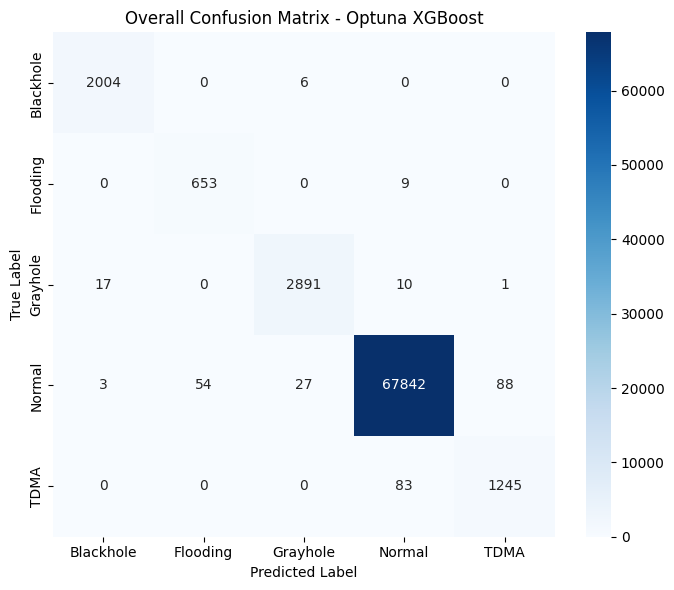

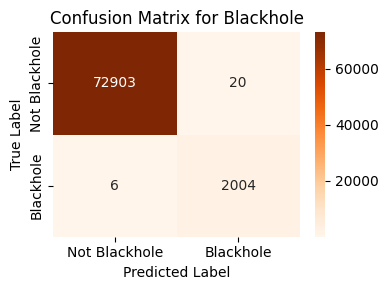

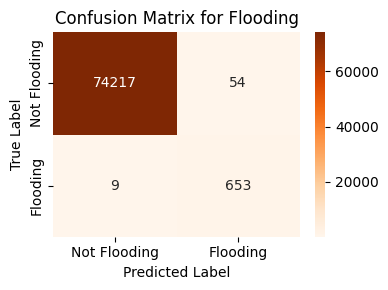

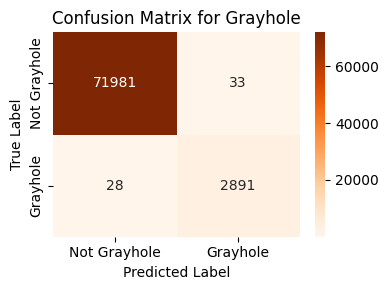

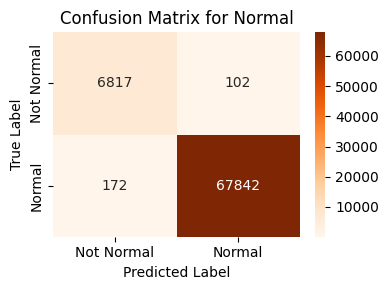

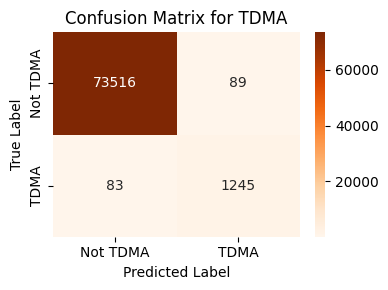

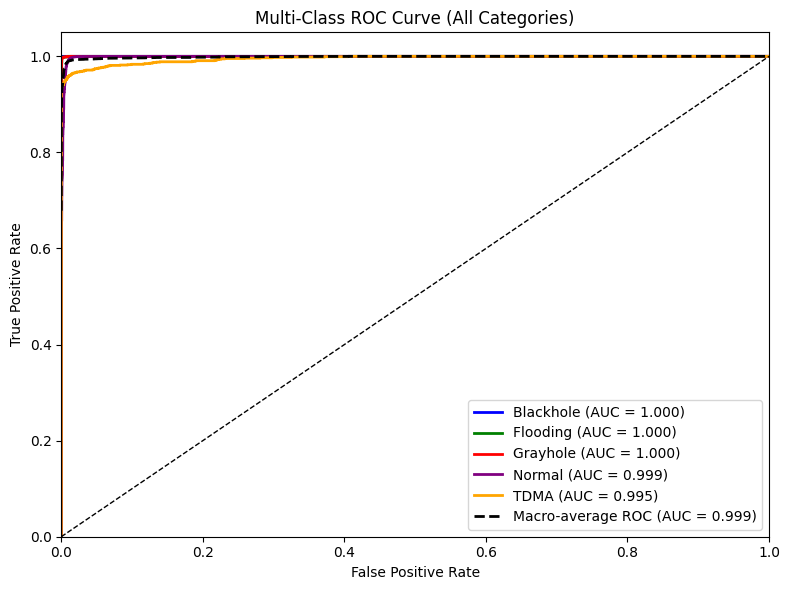

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np
import os

# Assuming:
# y_test  → encoded test labels
# y_pred  → predicted labels (for best model)
# y_prob  → predicted probabilities (for best model)
# classes → ['Blackhole', 'Flooding', 'Greyhole', 'Normal', 'TDMA']
# OUTPUT_DIR is already defined

best_model = models['Optuna_XGBoost']   # choose the model you want to visualize
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)

# CONFUSION MATRIX (overall)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title("Overall Confusion Matrix - Optuna XGBoost")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix_overall.png"), dpi=300)
plt.show()

# CONFUSION MATRIX for EACH CLASS
for idx, cls in enumerate(classes):
    cm_binary = confusion_matrix((y_test == idx).astype(int),
                                 (y_pred == idx).astype(int))
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm_binary, annot=True, fmt='d', cmap='Oranges',
                xticklabels=['Not ' + cls, cls], yticklabels=['Not ' + cls, cls])
    plt.title(f"Confusion Matrix for {cls}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"confusion_matrix_{cls}.png"), dpi=300)
    plt.show()


# AU-ROC CURVE (MULTICLASS)
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# One-vs-Rest binarization
y_test_bin = label_binarize(y_test, classes=np.arange(len(classes)))

fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(classes))]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(len(classes)):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= len(classes)
roc_auc["macro"] = auc(all_fpr, mean_tpr)

# Plot ROC for all categories
plt.figure(figsize=(8, 6))
colors = cycle(['blue', 'green', 'red', 'purple', 'orange'])
for i, color in zip(range(len(classes)), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{classes[i]} (AUC = {roc_auc[i]:.3f})')

# Add macro-average curve
plt.plot(all_fpr, mean_tpr, color='black', lw=2, linestyle='--',
         label=f'Macro-average ROC (AUC = {roc_auc["macro"]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve (All Categories)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "multi_class_ROC_curve.png"), dpi=300)
plt.show()


In [ ]:
import joblib
joblib.dump(models, "all_models.pkl")


['all_models.pkl']

In [ ]:
# === SAVE TRAINED MODELS & VARIABLES ===
import joblib
import os

SAVE_DIR = "saved_state"
os.makedirs(SAVE_DIR, exist_ok=True)

# Save all trained models (dictionary)
joblib.dump(models, os.path.join(SAVE_DIR, "models.pkl"))

# Save label encoder & class list
joblib.dump(le, os.path.join(SAVE_DIR, "label_encoder.pkl"))
joblib.dump(classes, os.path.join(SAVE_DIR, "classes.pkl"))

# Save test data (small enough to reload later)
joblib.dump((X_test, y_test), os.path.join(SAVE_DIR, "test_data.pkl"))

print("✅ All models and essential variables saved in:", SAVE_DIR)


✅ All models and essential variables saved in: saved_state


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = "/content/drive/MyDrive/WSN_Project/saved_state"
os.makedirs(SAVE_DIR, exist_ok=True)


Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
!ls -R /content/drive/MyDrive | head -30


Mounted at /content/drive
/content/drive/MyDrive:
04_ICC_M-2_L3.gdoc
12th Marksheet.pdf
202307020043_GargeeRai.pdf
202307020043_MATLAB.pdf
202307020043.pdf
certificate.pdf
Classroom
Colab Notebooks
consumerism GPHJ
Data Visualization .pdf
DBMS Project
DBMS STUDENT PROJECT REPORT .gdoc
Document from Gargee Rai (1).pdf
Document from Gargee Rai (2).pdf
Document from Gargee Rai.pdf
f4970e5f-8f96-498f-b74f-56b01af81794.pdf.gdoc
Gargee_Oracle_certificate.pdf
Gargee Rai 202307020043 - 21BTCS11C06- Problem solving and Programming -Lab Manual.gdoc
GargeeRai_202307020043_NetflixCaseStudy_pdf.pdf
GargeeRai_43-MentorMentee.pdf
LinkedIn Learning Certificate (1).pdf
LinkedIn Learning Certificate (2).pdf
LinkedIn Learning Certificate.pdf
LinkedIn Learning Certificates
NetflixCaseStudy_pdf (1).pdf
NetflixCaseStudy_pdf.pdf
Netflix_CaseStudy_ppt-compressed (2).pdf
Netflix_CaseStudy_ppt-compressed.pdf
Payment 150.jpg


In [ ]:
import os
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for f in files:
        if f.endswith('.pkl'):
            print(os.path.join(root, f))


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# Ensure same order of labels as in test set
label_order = np.arange(len(classes))

# Make directory
OUTPUT_DIR = "outputs_training_confusions"
os.makedirs(OUTPUT_DIR, exist_ok=True)

for name, model in models.items():
    print(f"Generating training confusion matrix for: {name}")
    y_pred_train = model.predict(X_train_res)

    # Ensure missing classes are represented (even if 0 count)
    cm_train = confusion_matrix(y_train_res, y_pred_train, labels=label_order)

    plt.figure(figsize=(7,6))
    sns.heatmap(cm_train, annot=True, fmt='d', cmap='Oranges',
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix (Training) - {name}')
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/confusion_train_{name}.png")
    plt.close()

# --- Overall Confusion Matrix for Training Set (Majority Voting) ---
from scipy.stats import mode

# Collect predictions from all models
train_preds = np.array([model.predict(X_train_res) for model in models.values()])
majority_preds, _ = mode(train_preds, axis=0)

# Compute confusion matrix for ensemble
cm_overall_train = confusion_matrix(y_train_res, majority_preds, labels=label_order)

plt.figure(figsize=(8,6))
sns.heatmap(cm_overall_train, annot=True, fmt='d', cmap='Oranges',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Overall Confusion Matrix - Training Set (Majority Voting)')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_overall_training.png")
plt.close()

print("✅ All training confusion matrices (5-category) saved in:", OUTPUT_DIR)


Generating training confusion matrix for: RandomForest
Generating training confusion matrix for: LinearSVM
Generating training confusion matrix for: NaiveBayes
Generating training confusion matrix for: Optuna_XGBoost
✅ All training confusion matrices (5-category) saved in: outputs_training_confusions
